<a href="https://colab.research.google.com/github/Midhula13/DSA0404-Fundamentals-of-data-science/blob/main/Python_library_problems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
raw_data = {
  "Employee_Name": [" Alice ", "Bob", "Charlie", "Diana", "Evan"],
  "Department": ["HR", "Engineering", "HR", "Engineering", "Marketing"],
  "Salary": [50000, 85000, np.nan, 92000, 60000],  # Missing value
  "Join_Date": [
  "2022-01-15",
  "2021-06-20",
  "2023-03-11",
  "2020-11-01",
  "2024-02-28",
  ],
  }
df = pd.DataFrame(raw_data)
print("--- Raw Data ---")
print(df, "\n")

--- Raw Data ---
  Employee_Name   Department   Salary   Join_Date
0        Alice            HR  50000.0  2022-01-15
1           Bob  Engineering  85000.0  2021-06-20
2       Charlie           HR      NaN  2023-03-11
3         Diana  Engineering  92000.0  2020-11-01
4          Evan    Marketing  60000.0  2024-02-28 



In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
df["Employee_Name"] = df["Employee_Name"].str.strip()

median_salary = df["Salary"].median()
df["Salary"] = df["Salary"].fillna(median_salary)
# Convert string dates into proper datetime format
df["Join_Date"] = pd.to_datetime(df["Join_Date"])
# Create a calculated feature (Years of service based on current year 2026)
df["Years_of_Service"] = 2026 - df["Join_Date"].dt.year
print("--- Preprocessed Data ---")
print(df, "\n")

--- Preprocessed Data ---
  Employee_Name   Department   Salary  Join_Date  Years_of_Service
0         Alice           HR  50000.0 2022-01-15                 4
1           Bob  Engineering  85000.0 2021-06-20                 5
2       Charlie           HR  72500.0 2023-03-11                 3
3         Diana  Engineering  92000.0 2020-11-01                 6
4          Evan    Marketing  60000.0 2024-02-28                 2 



In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
dept_summary = (
  df.groupby("Department")
  .agg(Avg_Salary=("Salary", "mean"), Total_Employees=("Employee_Name", "count"))
  .reset_index()
  )
print("--- Aggregated Summary ---")
print(dept_summary, "\n")

--- Aggregated Summary ---
    Department  Avg_Salary  Total_Employees
0  Engineering     88500.0                2
1           HR     61250.0                2
2    Marketing     60000.0                1 



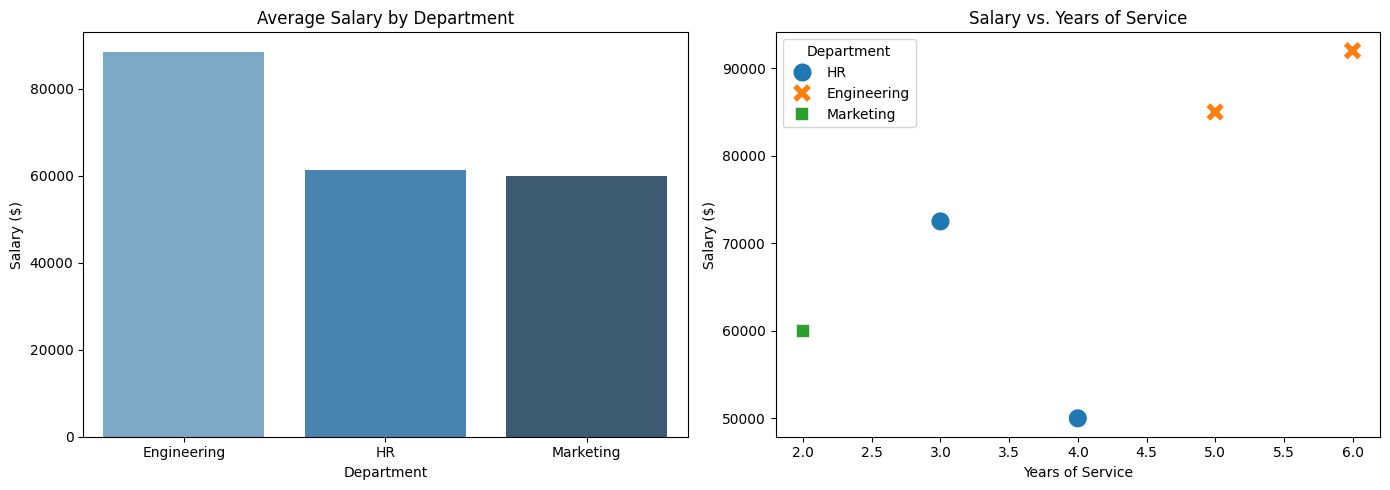

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot 1: Bar chart of average salaries across departments
sns.barplot(
data=dept_summary,
x="Department",
y="Avg_Salary",
hue="Department",
ax=axes[0],
palette="Blues_d",
legend=False,
)
axes[0].set_title("Average Salary by Department")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Salary ($)")
# Plot 2: Scatter plot mapping experience against compensation
sns.scatterplot(
data=df,
x="Years_of_Service",
y="Salary",
hue="Department",
style="Department",
s=200,
ax=axes[1],
)
axes[1].set_title("Salary vs. Years of Service")
axes[1].set_xlabel("Years of Service")
axes[1].set_ylabel("Salary ($)")
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
df = pd.DataFrame()
df['Name'] = ['John', 'Emma', 'Liam', 'Olivia']
df['Age'] = [20, 19, 21, 18]
df['Student'] = [True, True, False, True]
print(df)

     Name  Age  Student
0    John   20     True
1    Emma   19     True
2    Liam   21    False
3  Olivia   18     True


In [9]:
new_row = pd.DataFrame([['Sophia', 22, False]], columns=['Name', 'Age', 'Student'])
df = pd.concat([df, new_row], ignore_index=True)
print(df)

     Name  Age  Student
0    John   20     True
1    Emma   19     True
2    Liam   21    False
3  Olivia   18     True
4  Sophia   22    False


In [10]:
from scipy import stats
import numpy as np
data = [10, 20, 30, 40, 50]
print("Mean:", np.mean(data))
print("Median:", np.median(data))
print("Mode:", stats.mode(data))

Mean: 30.0
Median: 30.0
Mode: ModeResult(mode=np.int64(10), count=np.int64(1))


In [12]:
from scipy.stats import norm
probability = norm.cdf(85, loc=70, scale=10)
print("Probability:", probability)

Probability: 0.9331927987311419


In [13]:
from scipy import stats
data = [22, 25, 19, 24, 28, 30]
t_stat, p_value = stats.ttest_1samp(data, 25)
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -0.2049800154226962
P-Value: 0.8456711339658732


In [15]:
from scipy.stats import pearsonr
x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]
corr, p_value = pearsonr(x, y)
print("Correlation:", corr)

Correlation: 1.0


In [17]:
import numpy as np
A = [[3, 2], [1, 2]]
B = [5, 5]
solution = np.linalg.solve(A, B)
print(solution)

[0.  2.5]


In [19]:
from scipy.optimize import minimize
def objective(x):
    return x**2 + 4
result = minimize(objective, x0=5)
print(result.x)

[-2.62955131e-08]


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
iris = datasets.load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [21]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
iris = load_iris()
kmeans = KMeans(n_clusters=3)
kmeans.fit(iris.data)
cluster_labels = kmeans.labels_
print("Cluster Labels:", cluster_labels)

Cluster Labels: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 1
 1 1 0 0 1 1 1 1 0 1 0 1 0 1 1 0 0 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 0 1
 1 0]
